In [ ]:
import os
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt  
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

# Information

In [2]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import copy

In [6]:
data_transforms = {
    'see': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224)]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])]),
    'val_resize': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])]),
    'see_flip': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1)]),
    'flip': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])])
    }
model = torchvision.models.alexnet(pretrained=True)
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [7]:
def barplot(data):
    """data: such as (5,20)"""
    palette = ['#2f455c', '#39678d', '#5c898e', '#86aaa0', '#b5cdb5']
    plt.rcParams['font.family'] = 'Arial'       # 设置全局字体为无衬线字体Arial
    plt.rcParams['font.size'] = 12              # 全局字体大小8pt（根据期刊要求调整）
    plt.rcParams['axes.linewidth'] = 1.5       # 坐标轴线宽1.5pt
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(4,5), dpi=300)
    sns.barplot(data=data, alpha=0.85, palette=palette, errorbar='se', capsize=0.1)
    ax.set_xticks([0,1,2,3,4],['Intact', 'noEyes.', 'Upper', 'Lower', 'Eyes'], rotation=30)
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    plt.annotate('', 
                 xy=(1.1, 0), xycoords='axes fraction',
                 xytext=(-0.06, 0), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    # 绘制 y 轴方向的箭头
    plt.annotate('', 
                 xy=(0, 1.1), xycoords='axes fraction',
                 xytext=(0, -0.06), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    plt.show()

def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min())

In [8]:
Grayscale_Cam = []
for condition in ['face', 'noeye', 'top_face', 'down_face', 'eyes']:
    files_dir = r'Stim_for_model\\' + condition + '\\'
    classifier = torch.load(r'D:\TDCNN\SHNN\Transfer_AexNet', weights_only=False)
    model_classifier = copy.deepcopy(model)
    model_classifier.classifier._modules['7'] = classifier
    files = os.listdir(files_dir)
    Grayscale_cam = []
    for index,pic in enumerate(files):
        img = Image.open(files_dir+pic).convert('RGB')
        im = data_transforms['see'](img)
        picimg = data_transforms['val'](img)
        picimg = picimg.unsqueeze(0)    
        target_layers = [model_classifier.features[10]]
        input_tensor = picimg    
        cam = GradCAM(model=model_classifier, target_layers=target_layers)
        targets = [ClassifierOutputTarget(1)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        Grayscale_cam.append(grayscale_cam)
    Grayscale_Cam.append(np.array(Grayscale_cam))
Grayscale_Cam = np.array(Grayscale_Cam)

(-0.5, 223.5, 223.5, -0.5)

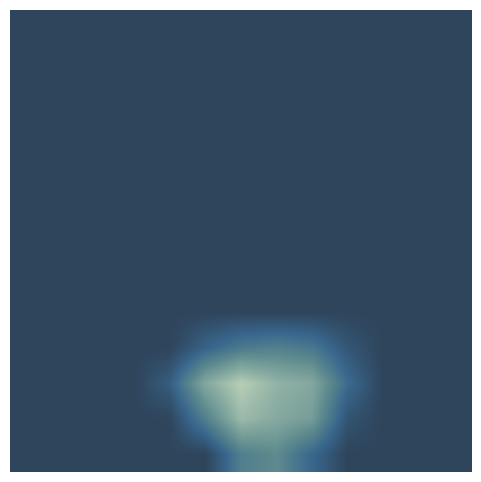

In [9]:
from matplotlib.colors import LinearSegmentedColormap

# 定义自定义色条的颜色列表
custom_colors = ['#2f455c', '#39678d', '#5c898e', '#86aaa0', '#b5cdb5']
# 创建线性插值色条
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', custom_colors)

plt.figure(figsize=(6,6), dpi=100)
im = plt.imshow(Grayscale_Cam[3,0], cmap=custom_cmap)
plt.axis('off')
# plt.colorbar(im, fraction=0.046, pad=0.04)  # 可选：显示色条

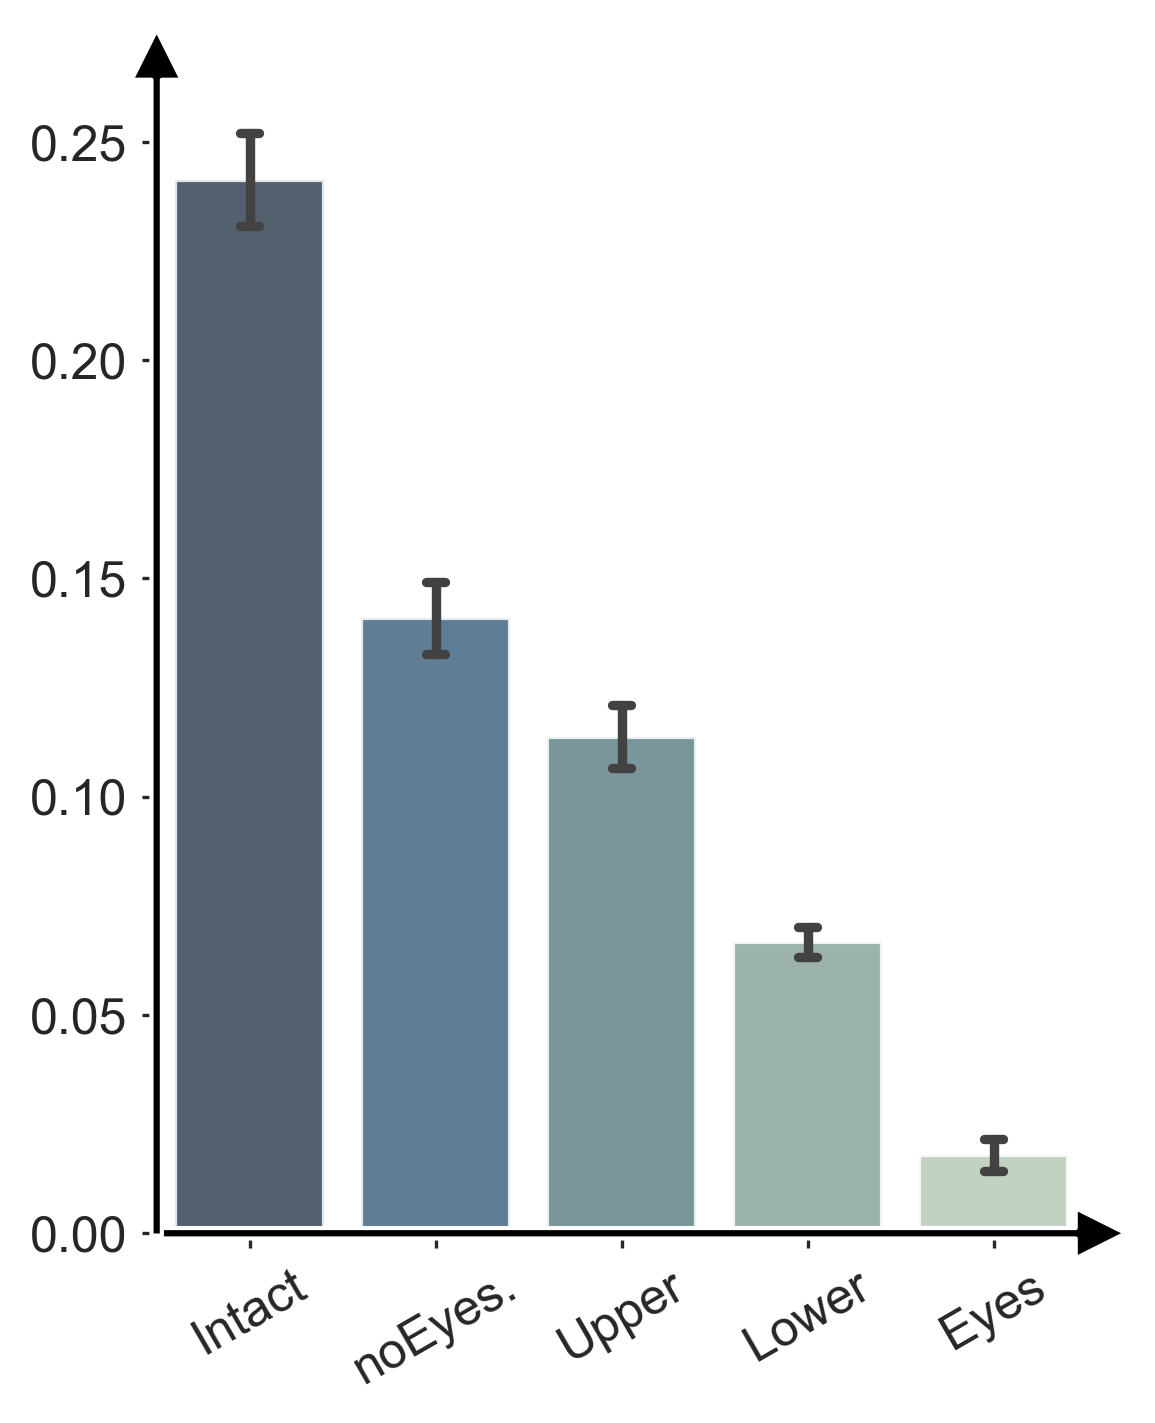

In [10]:
data = Grayscale_Cam.mean((2,3))
barplot(pd.DataFrame(data.T))